In [1]:
import numpy as np
from ofdm.modem import get_modem
from ofdm.candf import oversample_time, scf2
from ofdm.plots import plot_dataset_mapping, plot_ccdf_compare, plot_ccdf
import torch
from nnscf import normalize, denormalize
import os
import time
from ofdm.metrics import calculate_cm

In [2]:
# Parameters
N = 256                 # Number of Subcarriers
L = 4                   # Oversampling Factor
samples_per_L = 10000   # High value to capture the CCDF tail
cr_dB = 6
cr = 10 ** (cr_dB / 20)
iterations = 3

# Modulation scheme
mod = "16qam"
# mod = "qpsk"
if mod == "16qam":
    M = 16
elif mod == "qpsk":
    M = 4
modulate, _ = get_modem(M)

# Number of entries in the dataset
data_size = 100
train_size = 70

params = f"SCF {mod.upper()} (N={N}, L={L}, CR={cr_dB}dB)"

raw_dir = "./raw/"
relev_dir = "./relev/"
norm_dir = "./norm/"
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(relev_dir, exist_ok=True)
os.makedirs(norm_dir, exist_ok=True)

data_size_minus_samples_per_L_loop = 0
samples_per_L_minus_scf_time = 0
scf_time = 0

In [3]:
raw_limits = {
    'X_r_min': [],
    'X_r_max': [],
    'Y_r_min': [],
    'Y_r_max': [],
    'X_i_min': [],
    'X_i_max': [],
    'Y_i_min': [],
    'Y_i_max': []
}

def normalize_new(raw, limits):
    min, max = limits
    norm = 2.0 * ((raw - min) / (max - min)) - 1.0 if max != min else raw
    return norm

In [4]:
before_loop = time.time()
for i in range(data_size):
    loop_start = time.time() if i else before_loop
    tx_time, rx_time = [[], []], [[], []]
    for _ in range(samples_per_L):
        t1 = time.time()
        tx_data = np.random.randint(0, M, N)
        tx_symbols = modulate(tx_data)

        # Oversample and convert to time domain
        x_time = oversample_time(tx_symbols, N, L)

        # separately store real and imag parts (needed to generate data for NN model training)
        tx_time[0].append(np.real(x_time).astype(np.float32, copy=False))
        tx_time[1].append(np.imag(x_time).astype(np.float32, copy=False))

        t2 = time.time()
        samples_per_L_minus_scf_time += t2 - t1

        # Process SCF (1 Step replacing the 3 ICF iterations)
        x_scf, _, _ = scf2(x_time, cr, N, iterations=iterations)

        t3 = time.time()
        scf_time += t3 - t2

        # store the final iteration's real and imag parts separately
        rx_time[0].append(np.real(x_scf).astype(np.float32, copy=False))
        rx_time[1].append(np.imag(x_scf).astype(np.float32, copy=False))
        t4 = time.time()
        samples_per_L_minus_scf_time += t4 - t3
    t5 = time.time()

    tx_time = np.array(tx_time, dtype=np.float32)
    rx_time = np.array(rx_time, dtype=np.float32)

    # Extract Real and Imaginary arrays and extract exact physical limits
    X_real_norm, (X_r_min, X_r_max) = normalize(tx_time[0])
    X_imag_norm, (X_i_min, X_i_max) = normalize(tx_time[1])
    Y_real_norm, (Y_r_min, Y_r_max) = normalize(rx_time[0])
    Y_imag_norm, (Y_i_min, Y_i_max) = normalize(rx_time[1])

    # Save Real File as PyTorch Dictionary
    # ! Saving them in raw_dir even though they are normalized
    # ! This is because they will be renormalized again
    torch.save({
        'X_norm': X_real_norm.detach().clone().to(torch.float32),
        'Y_norm': Y_real_norm.detach().clone().to(torch.float32),
        'X_min': X_r_min, 'X_max': X_r_max,
        'Y_min': Y_r_min, 'Y_max': Y_r_max
    }, os.path.join(raw_dir, f"old_method_{i:02d}_real.pt"))

    # Save Imaginary File as PyTorch Dictionary
    torch.save({
        'X_norm': X_imag_norm.detach().clone().to(torch.float32),
        'Y_norm': Y_imag_norm.detach().clone().to(torch.float32),
        'X_min': X_i_min, 'X_max': X_i_max,
        'Y_min': Y_i_min, 'Y_max': Y_i_max
    }, os.path.join(raw_dir, f"old_method_{i:02d}_imag.pt"))


    # Save Real File as PyTorch Dictionary
    # ! turn into tensors to avoid weights_only error
    torch.save({
        'X_raw': torch.tensor(tx_time[0], dtype=torch.float32),
        'Y_raw': torch.tensor(rx_time[0], dtype=torch.float32)
    }, os.path.join(raw_dir, f"new_method_{i:02d}_real.pt"))

    # Save Imaginary File as PyTorch Dictionary
    torch.save({
        'X_raw': torch.tensor(tx_time[1], dtype=torch.float32),
        'Y_raw': torch.tensor(rx_time[1], dtype=torch.float32)
    }, os.path.join(raw_dir, f"new_method_{i:02d}_imag.pt"))

    # Save raw data limits
    raw_limits['X_r_min'].append(tx_time[0].min())
    raw_limits['X_r_max'].append(tx_time[0].max())
    raw_limits['Y_r_min'].append(rx_time[0].min())
    raw_limits['Y_r_max'].append(rx_time[0].max())
    raw_limits['X_i_min'].append(tx_time[1].min())
    raw_limits['X_i_max'].append(tx_time[1].max())
    raw_limits['Y_i_min'].append(rx_time[1].min())
    raw_limits['Y_i_max'].append(rx_time[1].max())

    # Manually delete variables to free RAM for the next iteration
    del tx_time, rx_time
    # gc.collect()

    loop_end = time.time()
    print(f"Iteration {i + 1}/{data_size} completed in {loop_end - loop_start:.2f} seconds")
    print(f"{loop_end - before_loop:.2f} seconds passed since before loop start")
    t6 = time.time()
    data_size_minus_samples_per_L_loop += t6 - t5

torch.save(raw_limits, os.path.join(relev_dir, f"new_method_raw_limits.pt"))

Iteration 1/100 completed in 4.30 seconds
4.30 seconds passed since before loop start
Iteration 2/100 completed in 4.16 seconds
8.46 seconds passed since before loop start
Iteration 3/100 completed in 3.68 seconds
12.14 seconds passed since before loop start
Iteration 4/100 completed in 3.21 seconds
15.34 seconds passed since before loop start
Iteration 5/100 completed in 5.14 seconds
20.48 seconds passed since before loop start
Iteration 6/100 completed in 4.80 seconds
25.28 seconds passed since before loop start
Iteration 7/100 completed in 3.28 seconds
28.56 seconds passed since before loop start
Iteration 8/100 completed in 3.15 seconds
31.71 seconds passed since before loop start
Iteration 9/100 completed in 3.23 seconds
34.95 seconds passed since before loop start
Iteration 10/100 completed in 5.15 seconds
40.10 seconds passed since before loop start
Iteration 11/100 completed in 4.69 seconds
44.79 seconds passed since before loop start
Iteration 12/100 completed in 3.45 seconds


In [5]:
print(f"--- STEP 1: Finding Global Limits from Training Data (Files 0 to {train_size} - 1) ---")
# Initialize global trackers
g_X_r_min, g_X_r_max = float('inf'), float('-inf')
g_Y_r_min, g_Y_r_max = float('inf'), float('-inf')
g_X_i_min, g_X_i_max = float('inf'), float('-inf')
g_Y_i_min, g_Y_i_max = float('inf'), float('-inf')

--- STEP 1: Finding Global Limits from Training Data (Files 0 to 70 - 1) ---


In [6]:
# Only scan the first train_size files to prevent Data Leakage!
for i in range(train_size):
    # Load dictionaries
    real_path_og = os.path.join(raw_dir, f"old_method_{i:02d}_real.pt")
    imag_path_og = os.path.join(raw_dir, f"old_method_{i:02d}_imag.pt")

    data_real = torch.load(real_path_og, weights_only=True)
    data_imag = torch.load(imag_path_og, weights_only=True)

    # Extract local limits and update globals
    g_X_r_min = min(g_X_r_min, data_real['X_min'])
    g_X_r_max = max(g_X_r_max, data_real['X_max'])
    g_Y_r_min = min(g_Y_r_min, data_real['Y_min'])
    g_Y_r_max = max(g_Y_r_max, data_real['Y_max'])

    g_X_i_min = min(g_X_i_min, data_imag['X_min'])
    g_X_i_max = max(g_X_i_max, data_imag['X_max'])
    g_Y_i_min = min(g_Y_i_min, data_imag['Y_min'])
    g_Y_i_max = max(g_Y_i_max, data_imag['Y_max'])
    print(f"Found Local Real X Limits: Min = {data_real['X_min']:.4f}, Max = {data_real['X_max']:.4f}")

print(f"Found Global Real X Limits: Min = {g_X_r_min:.4f}, Max = {g_X_r_max:.4f}")

Found Local Real X Limits: Min = -0.2218, Max = 0.2346
Found Local Real X Limits: Min = -0.2322, Max = 0.2391
Found Local Real X Limits: Min = -0.2268, Max = 0.2417
Found Local Real X Limits: Min = -0.2227, Max = 0.2272
Found Local Real X Limits: Min = -0.2616, Max = 0.2287
Found Local Real X Limits: Min = -0.2384, Max = 0.2248
Found Local Real X Limits: Min = -0.2334, Max = 0.2325
Found Local Real X Limits: Min = -0.2275, Max = 0.2160
Found Local Real X Limits: Min = -0.2380, Max = 0.2463
Found Local Real X Limits: Min = -0.2325, Max = 0.2284
Found Local Real X Limits: Min = -0.2304, Max = 0.2363
Found Local Real X Limits: Min = -0.2314, Max = 0.2226
Found Local Real X Limits: Min = -0.2266, Max = 0.2328
Found Local Real X Limits: Min = -0.2259, Max = 0.2282
Found Local Real X Limits: Min = -0.2309, Max = 0.2279
Found Local Real X Limits: Min = -0.2465, Max = 0.2249
Found Local Real X Limits: Min = -0.2181, Max = 0.2241
Found Local Real X Limits: Min = -0.2383, Max = 0.2154
Found Loca

In [7]:
print(f"\n--- STEP 2: Denormalizing and Renormalizing ALL {data_size} Files ---")
before_loop = time.time()
for i in range(data_size):
    loop_start = time.time() if i else before_loop

    real_path_og = os.path.join(raw_dir, f"old_method_{i:02d}_real.pt")
    imag_path_og = os.path.join(raw_dir, f"old_method_{i:02d}_imag.pt")

    data_real = torch.load(real_path_og, weights_only=True)
    data_imag = torch.load(imag_path_og, weights_only=True)

    # --- PROCESS REAL ---
    # 1. Denormalize back to raw physical voltages
    raw_X_r = denormalize(data_real['X_norm'], (data_real['X_min'], data_real['X_max']))
    raw_Y_r = denormalize(data_real['Y_norm'], (data_real['Y_min'], data_real['Y_max']))

    # todo: maybe i could make a function for that
    # 2. Renormalize using Global Limits
    data_real['X_norm'] = 2.0 * ((raw_X_r - g_X_r_min) / (g_X_r_max - g_X_r_min)) - 1.0 if g_X_r_max != g_X_r_min else raw_X_r
    data_real['Y_norm'] = 2.0 * ((raw_Y_r - g_Y_r_min) / (g_Y_r_max - g_Y_r_min)) - 1.0 if g_Y_r_max != g_Y_r_min else raw_Y_r

    # 3. OVERWRITE the old local limits with the global limits in the dictionary!
    data_real['X_min'], data_real['X_max'] = g_X_r_min, g_X_r_max
    data_real['Y_min'], data_real['Y_max'] = g_Y_r_min, g_Y_r_max

    # --- PROCESS IMAGINARY ---
    raw_X_i = denormalize(data_imag['X_norm'], (data_imag['X_min'], data_imag['X_max']))
    raw_Y_i = denormalize(data_imag['Y_norm'], (data_imag['Y_min'], data_imag['Y_max']))

    # todo: maybe i could make a function for that
    data_imag['X_norm'] = 2.0 * ((raw_X_i - g_X_i_min) / (g_X_i_max - g_X_i_min)) - 1.0 if g_X_i_max != g_X_i_min else raw_X_i
    data_imag['Y_norm'] = 2.0 * ((raw_Y_i - g_Y_i_min) / (g_Y_i_max - g_Y_i_min)) - 1.0 if g_Y_i_max != g_Y_i_min else raw_Y_i

    data_imag['X_min'], data_imag['X_max'] = g_X_i_min, g_X_i_max
    data_imag['Y_min'], data_imag['Y_max'] = g_Y_i_min, g_Y_i_max

    real_path_out = os.path.join(norm_dir, f"old_method_{i:02d}_real.pt")
    imag_path_out = os.path.join(norm_dir, f"old_method_{i:02d}_imag.pt")

    # Save files back to disk (overwriting)
    torch.save(data_real, real_path_out)
    torch.save(data_imag, imag_path_out)

    loop_end = time.time()
    print(f"Iteration {i + 1}/{data_size} completed in {loop_end - loop_start:.2f} seconds")
    print(f"{loop_end - before_loop:.2f} seconds passed since before loop start")

print("Data successfully updated with Global Normalization!")


--- STEP 2: Denormalizing and Renormalizing ALL 100 Files ---
Iteration 1/100 completed in 0.68 seconds
0.68 seconds passed since before loop start
Iteration 2/100 completed in 0.62 seconds
1.30 seconds passed since before loop start
Iteration 3/100 completed in 0.64 seconds
1.94 seconds passed since before loop start
Iteration 4/100 completed in 0.61 seconds
2.55 seconds passed since before loop start
Iteration 5/100 completed in 0.62 seconds
3.17 seconds passed since before loop start
Iteration 6/100 completed in 0.57 seconds
3.74 seconds passed since before loop start
Iteration 7/100 completed in 0.57 seconds
4.31 seconds passed since before loop start
Iteration 8/100 completed in 0.57 seconds
4.88 seconds passed since before loop start
Iteration 9/100 completed in 0.56 seconds
5.44 seconds passed since before loop start
Iteration 10/100 completed in 0.58 seconds
6.02 seconds passed since before loop start
Iteration 11/100 completed in 0.57 seconds
6.59 seconds passed since before 

In [8]:
lims = torch.load(os.path.join(relev_dir, f"new_method_raw_limits.pt"), weights_only=False)
X_r_limits = (min(lims["X_r_min"][:train_size]), max(lims["X_r_max"][:train_size]))
Y_r_limits = (min(lims["Y_r_min"][:train_size]), max(lims["Y_r_max"][:train_size]))
X_i_limits = (min(lims["X_i_min"][:train_size]), max(lims["X_i_max"][:train_size]))
Y_i_limits = (min(lims["Y_i_min"][:train_size]), max(lims["Y_i_max"][:train_size]))

# fixme: plots show that this normalization is incorrect
before_loop = time.time()
for i in range(data_size):
    loop_start = time.time() if i else before_loop

    real_path_raw = os.path.join(raw_dir, f"new_method_{i:02d}_real.pt")
    imag_path_raw = os.path.join(raw_dir, f"new_method_{i:02d}_imag.pt")

    data_real = torch.load(real_path_raw, weights_only=True)
    data_imag = torch.load(imag_path_raw, weights_only=True)

    X_r_norm = normalize_new(data_real['X_raw'], X_r_limits)
    Y_r_norm = normalize_new(data_real['Y_raw'], Y_r_limits)
    X_i_norm = normalize_new(data_imag['X_raw'], X_i_limits)
    Y_i_norm = normalize_new(data_imag['Y_raw'], X_i_limits)

    torch.save({
        'X_norm': X_r_norm,
        'Y_norm': Y_r_norm
    }, os.path.join(norm_dir, f"new_method_{i:02d}_real.pt"))

    torch.save({
        'X_norm': X_i_norm,
        'Y_norm': Y_i_norm
    }, os.path.join(norm_dir, f"new_method_{i:02d}_imag.pt"))

    loop_end = time.time()
    print(f"Iteration {i + 1}/{data_size} completed in {loop_end - loop_start:.2f} seconds")
    print(f"{loop_end - before_loop:.2f} seconds passed since before loop start")

Iteration 1/100 completed in 0.58 seconds
0.58 seconds passed since before loop start
Iteration 2/100 completed in 0.57 seconds
1.15 seconds passed since before loop start
Iteration 3/100 completed in 0.54 seconds
1.69 seconds passed since before loop start
Iteration 4/100 completed in 0.59 seconds
2.28 seconds passed since before loop start
Iteration 5/100 completed in 0.56 seconds
2.84 seconds passed since before loop start
Iteration 6/100 completed in 0.54 seconds
3.38 seconds passed since before loop start
Iteration 7/100 completed in 0.51 seconds
3.89 seconds passed since before loop start
Iteration 8/100 completed in 0.51 seconds
4.40 seconds passed since before loop start
Iteration 9/100 completed in 0.50 seconds
4.90 seconds passed since before loop start
Iteration 10/100 completed in 0.51 seconds
5.41 seconds passed since before loop start
Iteration 11/100 completed in 0.51 seconds
5.92 seconds passed since before loop start
Iteration 12/100 completed in 0.50 seconds
6.43 seco

In [24]:
tx_r_old = torch.load(os.path.join(raw_dir, f"old_method_{10:02d}_real.pt"))
tx_i_old = torch.load(os.path.join(raw_dir, f"old_method_{10:02d}_imag.pt"))
tx_r_norm_old = torch.load(os.path.join(norm_dir, f"old_method_{10:02d}_real.pt"))
tx_i_norm_old = torch.load(os.path.join(norm_dir, f"old_method_{10:02d}_imag.pt"))

tx_r_new = torch.load(os.path.join(raw_dir, f"new_method_{10:02d}_real.pt"))
tx_i_new = torch.load(os.path.join(raw_dir, f"new_method_{10:02d}_imag.pt"))
tx_r_norm_new = torch.load(os.path.join(norm_dir, f"new_method_{10:02d}_real.pt"))
tx_i_norm_new = torch.load(os.path.join(norm_dir, f"new_method_{10:02d}_imag.pt"))
lims = torch.load(os.path.join(relev_dir, f"new_method_raw_limits.pt"), weights_only=False)

In [25]:
XR_old, YR_old = tx_r_old['X_norm'], tx_r_old['Y_norm']
XI_old, YI_old = tx_i_old['X_norm'], tx_i_old['Y_norm']
xr_norm_old, yr_norm_old = tx_r_norm_old['X_norm'], tx_r_norm_old['Y_norm']
xi_norm_old, yi_norm_old = tx_i_norm_old['X_norm'], tx_i_norm_old['Y_norm']
xr_old = denormalize(xr_norm_old, (g_X_r_min, g_X_r_max))
yr_old = denormalize(yr_norm_old, (g_Y_r_min, g_Y_r_max))
xi_old = denormalize(xi_norm_old, (g_X_i_min, g_X_i_max))
yi_old = denormalize(yi_norm_old, (g_Y_i_min, g_Y_i_max))

XR_new, YR_new = tx_r_new['X_raw'], tx_r_new['Y_raw']
XI_new, YI_new = tx_i_new['X_raw'], tx_i_new['Y_raw']
xr_train_norm_new, xi_train_norm_new = tx_r_norm_new['X_norm'], tx_r_norm_new['Y_norm']
yr_train_norm_new, yi_train_norm_new = tx_i_norm_new['X_norm'], tx_i_norm_new['Y_norm']
xr_norm_new = normalize_new(XR_new, (lims['X_r_min'][0], lims['X_r_max'][0]))
yr_norm_new = normalize_new(YR_new, (lims['Y_r_min'][0], lims['Y_r_max'][0]))
xi_norm_new = normalize_new(XI_new, (lims['X_i_min'][0], lims['X_i_max'][0]))
yi_norm_new = normalize_new(YI_new, (lims['Y_i_min'][0], lims['Y_i_max'][0]))
xr_new = denormalize(xr_norm_new, (lims['X_r_min'][0], lims['X_r_max'][0]))
yr_new = denormalize(yr_norm_new, (lims['Y_r_min'][0], lims['Y_r_max'][0]))
xi_new = denormalize(xi_norm_new, (lims['X_i_min'][0], lims['X_i_max'][0]))
yi_new = denormalize(yi_norm_new, (lims['Y_i_min'][0], lims['Y_i_max'][0]))
xr_train_new = denormalize(xr_train_norm_new, X_r_limits)
yr_train_new = denormalize(yr_train_norm_new, Y_r_limits)
xi_train_new = denormalize(xi_train_norm_new, X_i_limits)
yi_train_new = denormalize(yi_train_norm_new, Y_i_limits)


In [26]:
X_old = XR_old.numpy() + 1j * XI_old.numpy()
Y_old = YR_old.numpy() + 1j * YI_old.numpy()
x_norm_old = xr_norm_old.numpy() + 1j * xi_norm_old.numpy()
y_norm_old = yr_norm_old.numpy() + 1j * yi_norm_old.numpy()
x_old = xr_old.numpy() + 1j * xi_old.numpy()
y_old = yr_old.numpy() + 1j * yi_old.numpy()

X_new = XR_new.numpy() + 1j * XI_new.numpy()
Y_new = YR_new.numpy() + 1j * YI_new.numpy()
x_train_norm_new = xr_train_norm_new.numpy() + 1j * xi_train_norm_new.numpy()
y_train_norm_new = yr_train_norm_new.numpy() + 1j * yi_train_norm_new.numpy()
x_norm_new = xr_norm_new.numpy() + 1j * xi_norm_new.numpy()
y_norm_new = yr_norm_new.numpy() + 1j * yi_norm_new.numpy()
x_new = xr_new.numpy() + 1j * xi_new.numpy()
y_new = yr_new.numpy() + 1j * yi_new.numpy()
x_train_new = xr_train_new.numpy() + 1j * xi_train_new.numpy()
y_train_new = yr_train_new.numpy() + 1j * yi_train_new.numpy()

In [27]:
X_cm_old, Y_cm_old, x_norm_cm_old, y_norm_cm_old, x_cm_old, y_cm_old  = [], [], [], [], [], []
for i in range(samples_per_L):
    X_cm_old.append(calculate_cm(X_old[i]))
    Y_cm_old.append(calculate_cm(Y_old[i]))
    x_norm_cm_old.append(calculate_cm(x_norm_old[i]))
    y_norm_cm_old.append(calculate_cm(y_norm_old[i]))
    x_cm_old.append(calculate_cm(x_old[i]))
    y_cm_old.append(calculate_cm(y_old[i]))

X_cm_new, Y_cm_new, x_train_norm_cm_new, y_train_norm_cm_new, x_norm_cm_new, y_norm_cm_new, x_cm_new, y_cm_new, x_train_cm_new, y_train_cm_new = [], [], [], [], [], [], [], [], [], []
for i in range(samples_per_L):
    X_cm_new.append(calculate_cm(X_new[i]))
    Y_cm_new.append(calculate_cm(Y_new[i]))
    x_train_norm_cm_new.append(calculate_cm(x_train_norm_new[i]))
    y_train_norm_cm_new.append(calculate_cm(y_train_norm_new[i]))
    x_norm_cm_new.append(calculate_cm(x_norm_new[i]))
    y_norm_cm_new.append(calculate_cm(y_norm_new[i]))
    x_cm_new.append(calculate_cm(x_new[i]))
    y_cm_new.append(calculate_cm(y_new[i]))
    x_train_cm_new.append(calculate_cm(x_train_new[i]))
    y_train_cm_new.append(calculate_cm(y_train_new[i]))

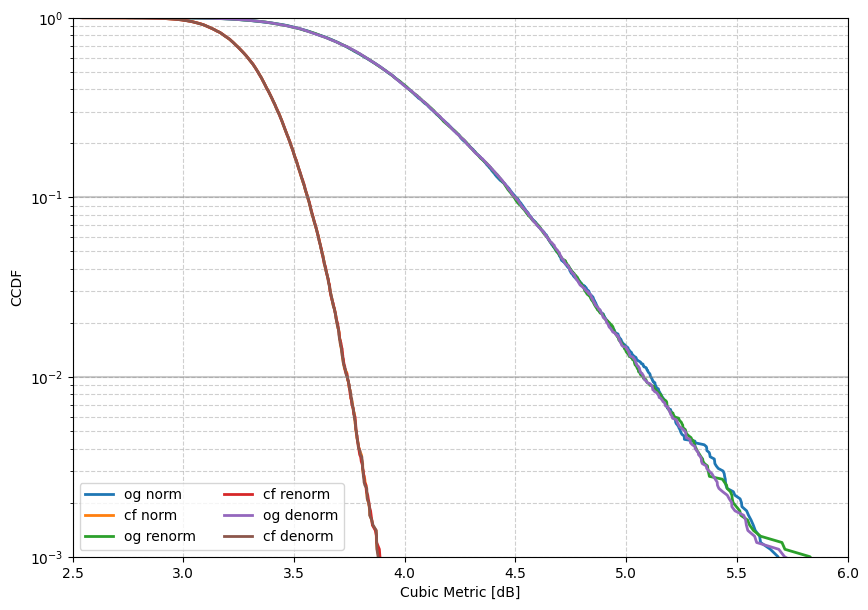

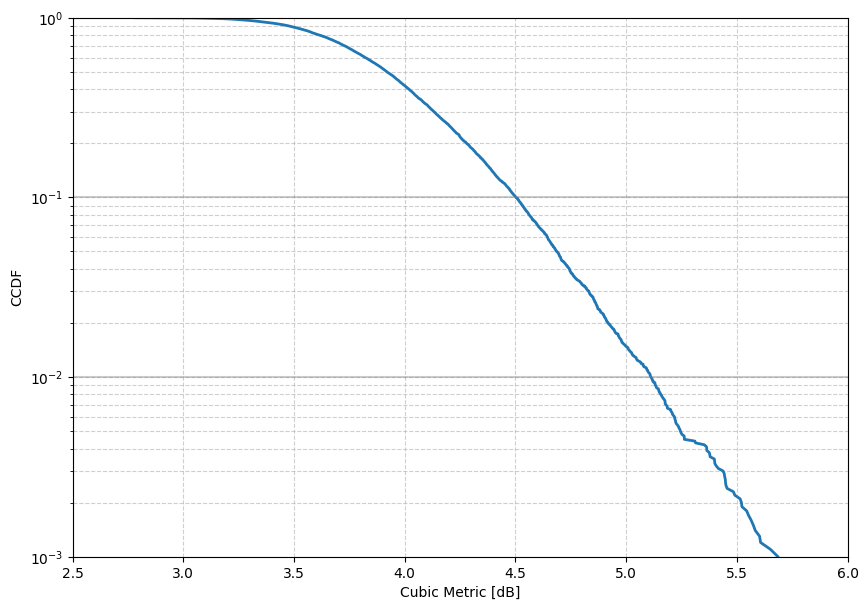

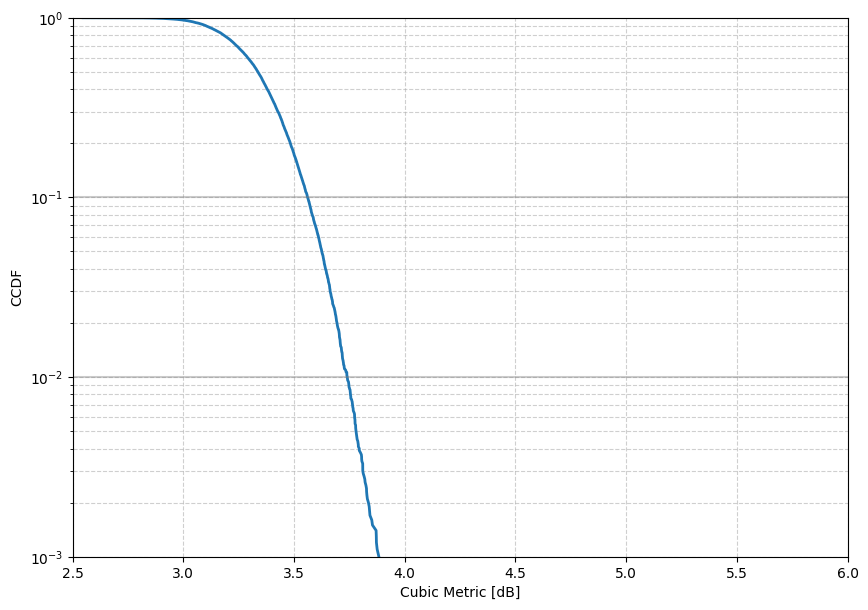

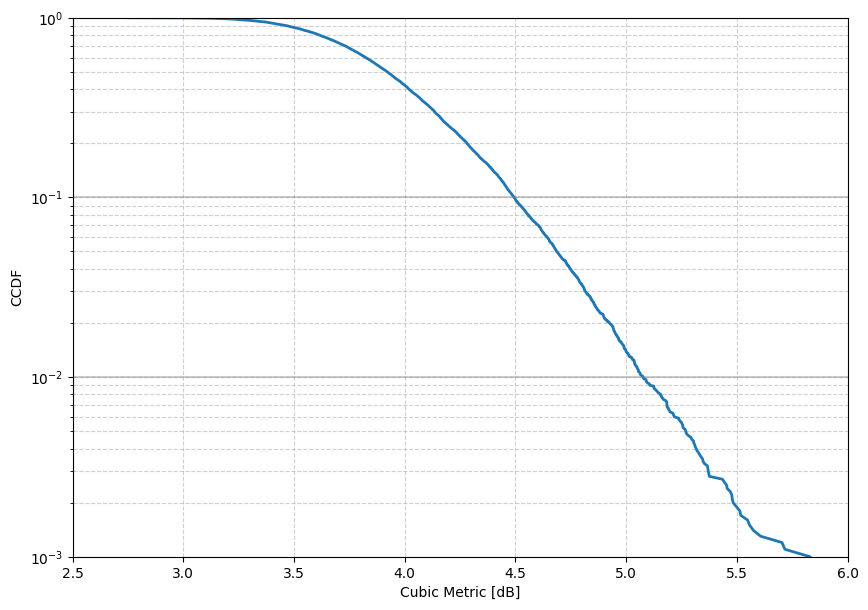

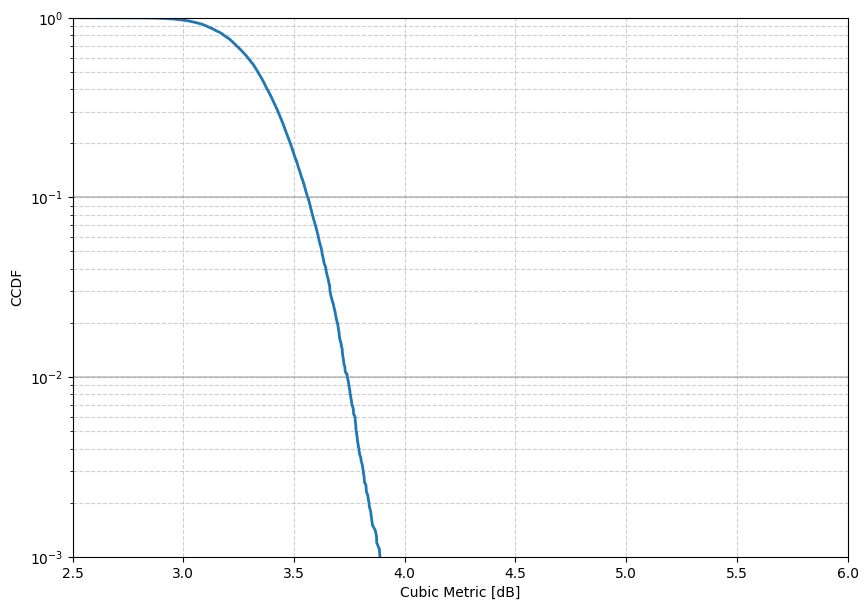

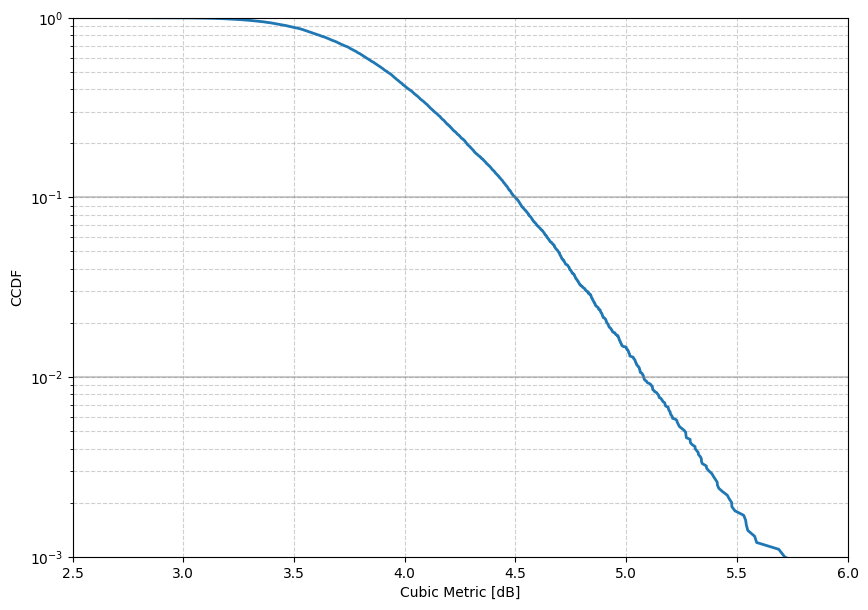

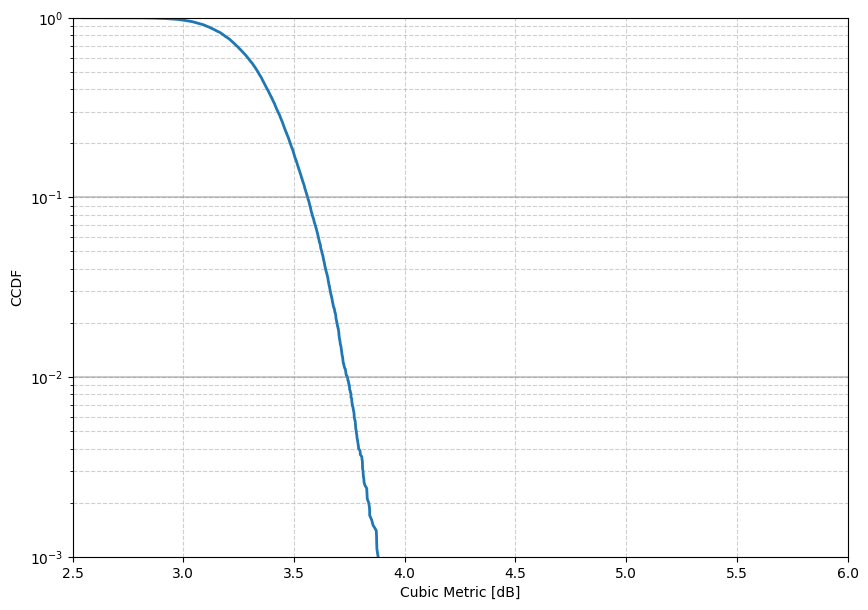

In [16]:
cm_list_old = [X_cm_old, Y_cm_old, x_norm_cm_old, y_norm_cm_old, x_cm_old, y_cm_old]

labels_old = ["og norm", "cf norm", "og renorm", "cf renorm", "og denorm", "cf denorm"]
plot_ccdf_compare(cm_list_old, label=labels_old, metric="CM")
for lst in cm_list_old:
    plot_ccdf(lst, metric="CM")
# plot_ccdf(X_cm_old, metric="CM")
# plot_ccdf(Y_cm_old, metric="CM")
# plot_ccdf(x_norm_cm_old, metric="CM")
# plot_ccdf(y_norm_cm_old, metric="CM")
# plot_ccdf(x_cm_old, metric="CM")
# plot_ccdf(y_cm_old, metric="CM")

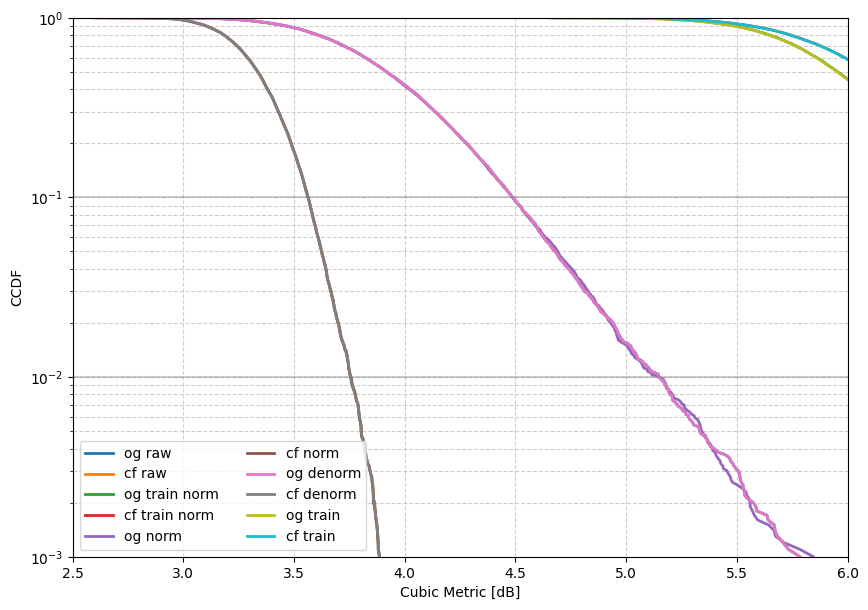

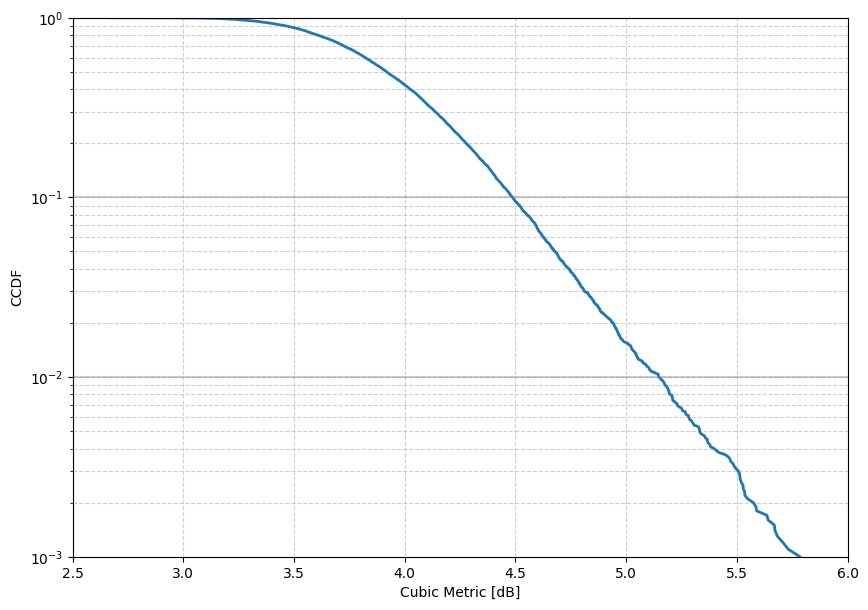

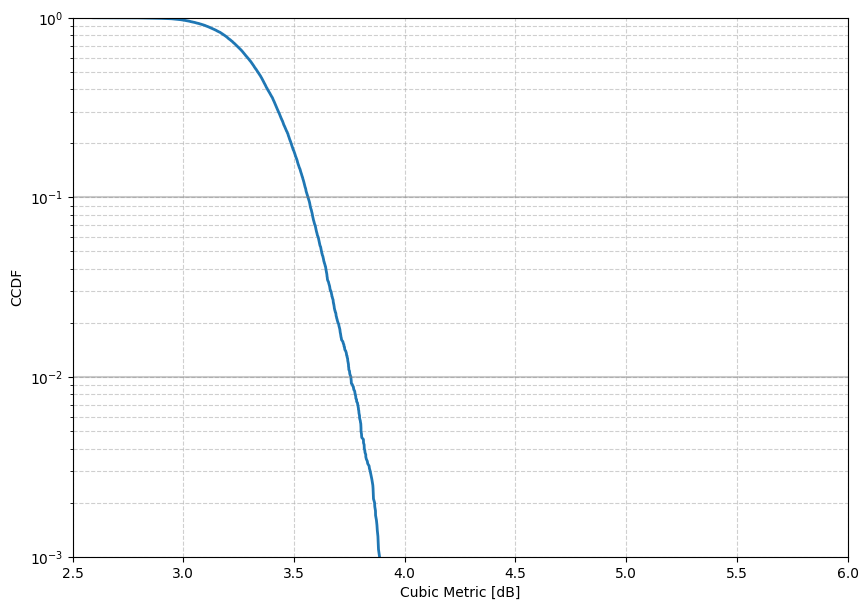

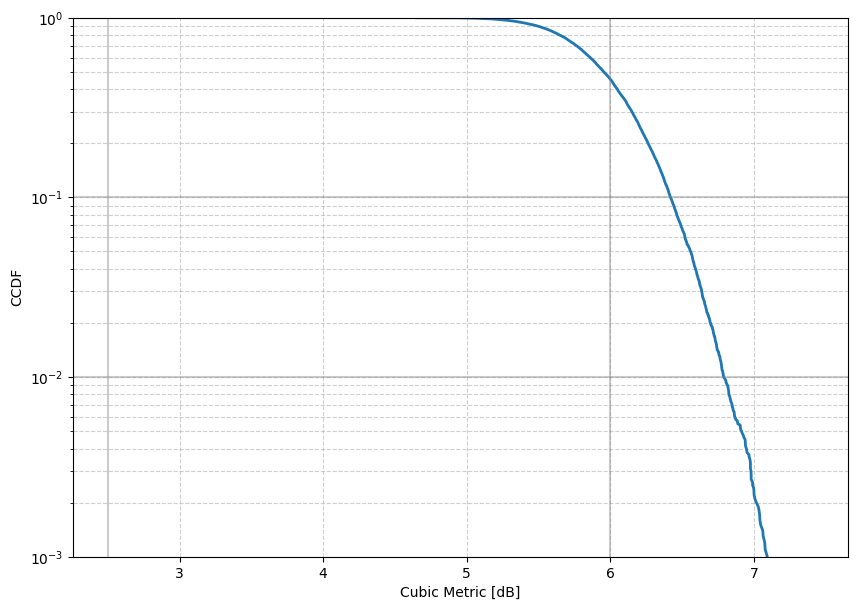

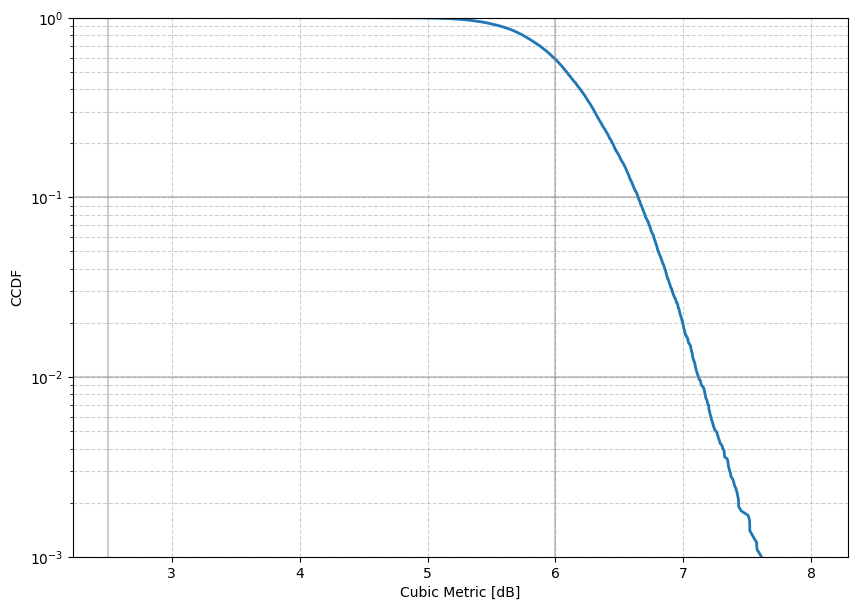

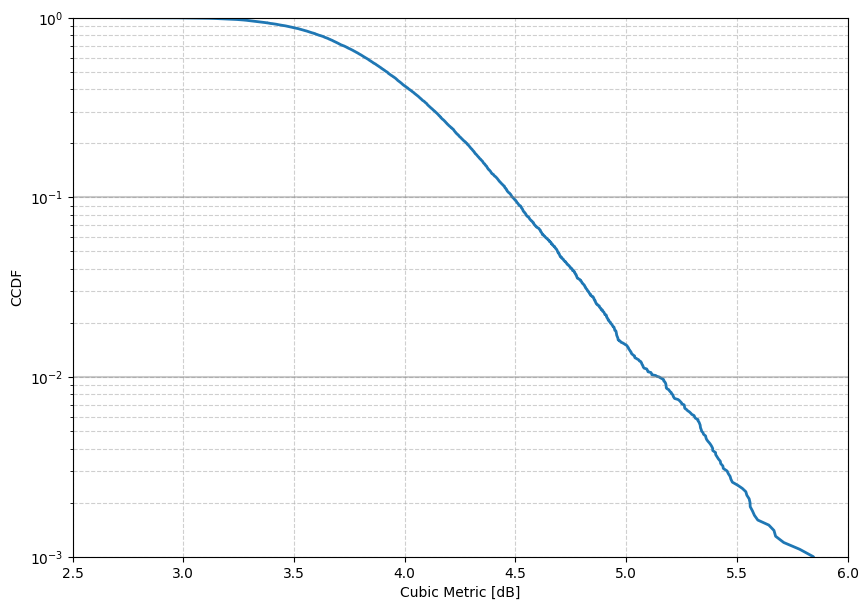

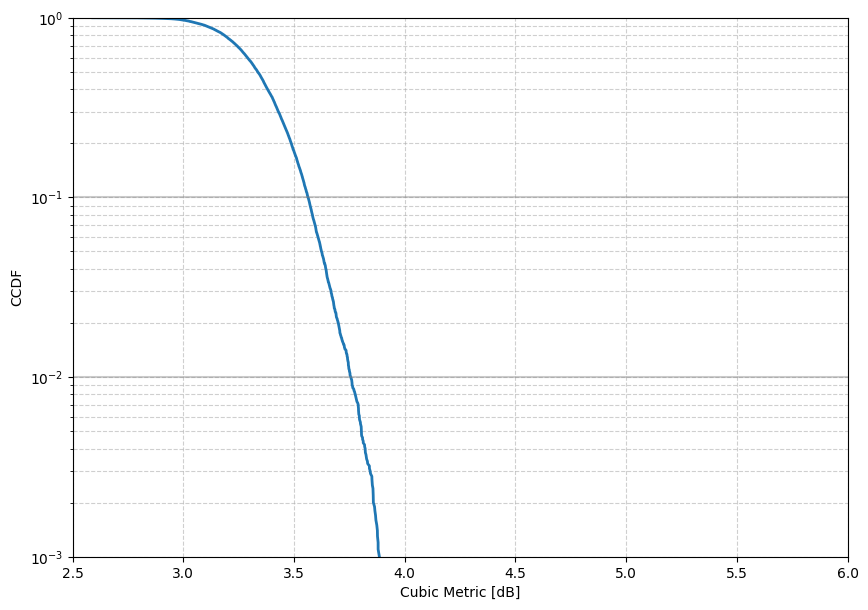

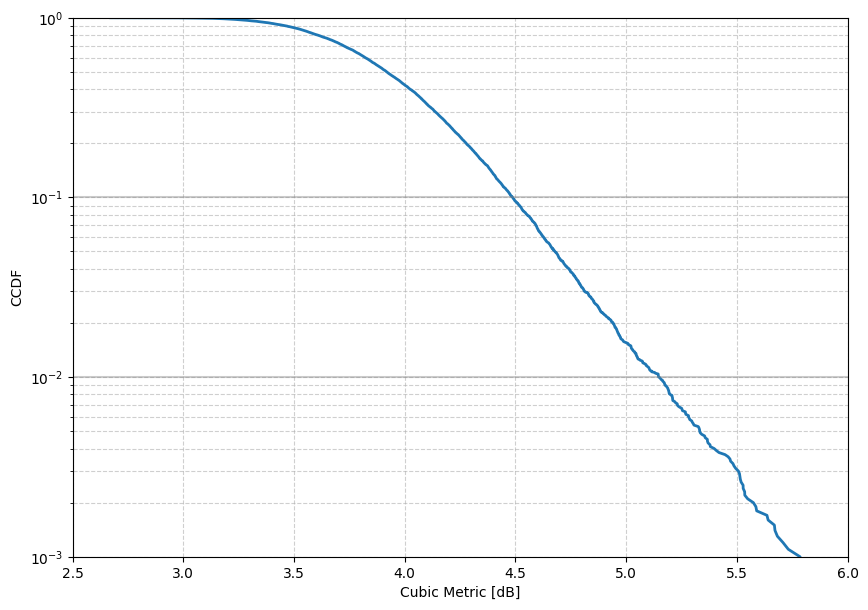

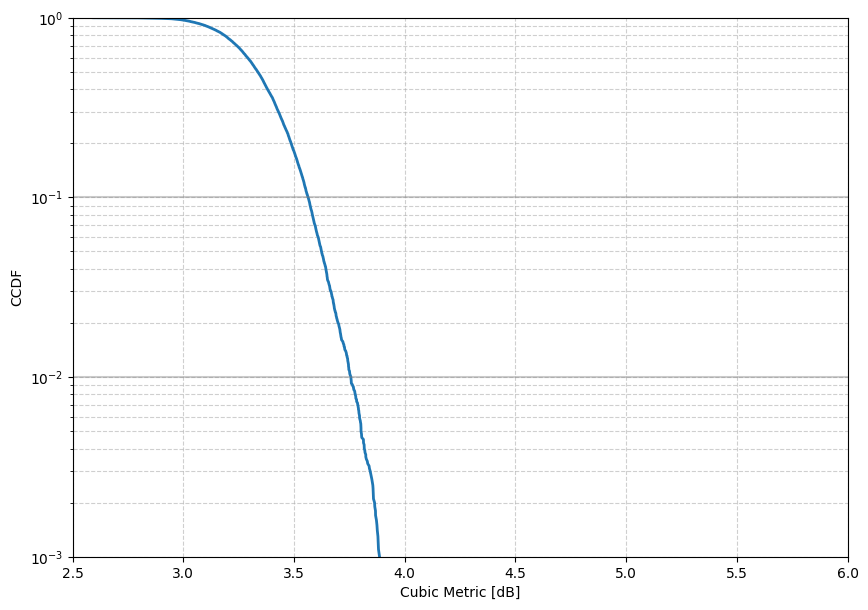

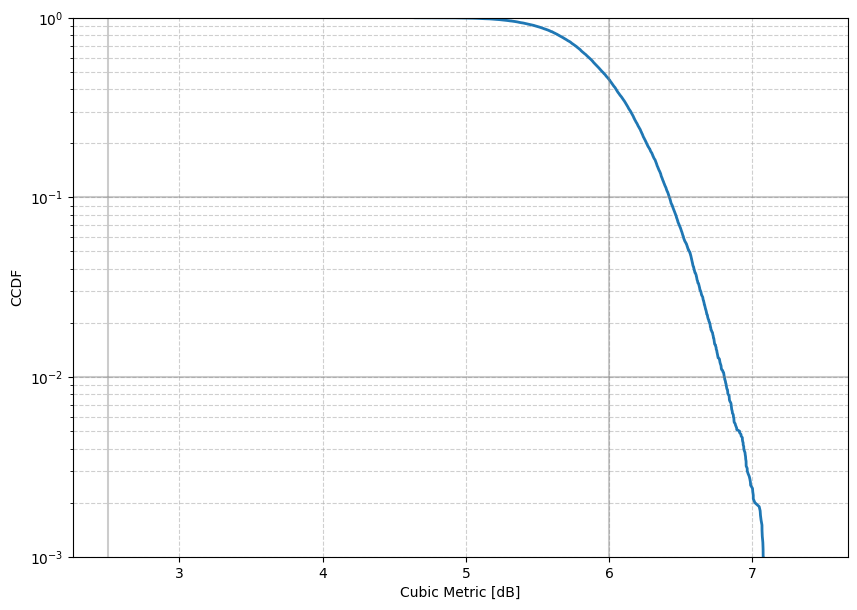

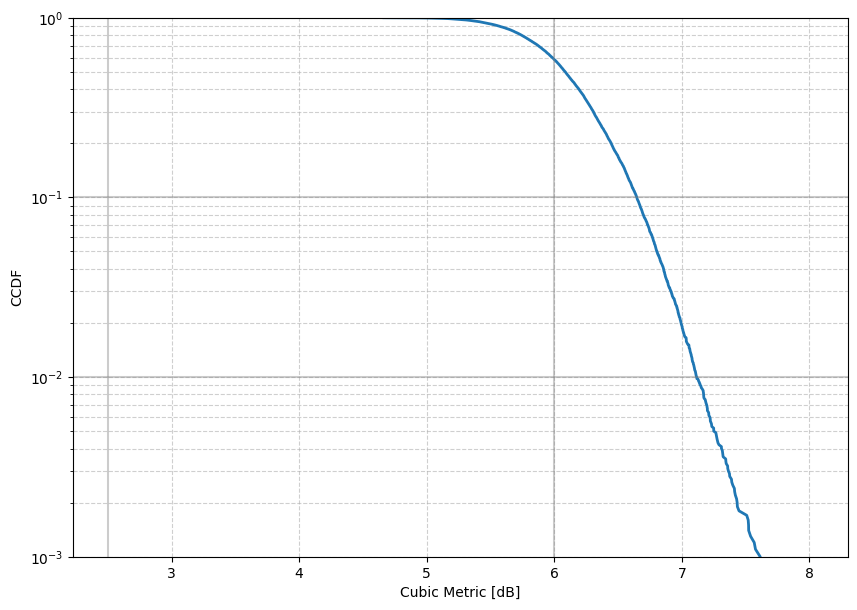

In [28]:
cm_list_new = [X_cm_new, Y_cm_new, x_train_norm_cm_new, y_train_norm_cm_new, x_norm_cm_new, y_norm_cm_new, x_cm_new, y_cm_new, x_train_cm_new, y_train_cm_new]

labels_new = ["og raw", "cf raw", "og train norm", "cf train norm", "og norm", "cf norm", "og denorm", "cf denorm", "og train", "cf train"]
plot_ccdf_compare(cm_list_new, label=labels_new, metric="CM")
for lst in cm_list_new:
    plot_ccdf(lst, metric="CM")
# plot_ccdf(X_cm_new, metric="CM")
# plot_ccdf(Y_cm_new, metric="CM")
# plot_ccdf(x_train_norm_cm_new, metric="CM")
# plot_ccdf(y_train_norm_cm_new, metric="CM")
# plot_ccdf(x_norm_cm_new, metric="CM")
# plot_ccdf(y_norm_cm_new, metric="CM")
# plot_ccdf(x_cm_new, metric="CM")
# plot_ccdf(y_cm_new, metric="CM")
# plot_ccdf(x_train_cm_new, metric="CM")
# plot_ccdf(y_train_cm_new, metric="CM")

In [18]:
# print("X_old == x_old", X_old == x_old)
print("np.allclose(X_old, x_old)", np.allclose(X_old, x_old))
# print("X_cm_old == x_cm_old", X_cm_old == x_cm_old)
print("np.allclose(X_cm_old, x_cm_old)", np.allclose(X_cm_old, x_cm_old))
print()
# print("x_norm_old == x_old", x_norm_old == x_old)
print("np.allclose(x_norm_old, x_old)", np.allclose(x_norm_old, x_old))
# print("x_norm_cm_old == x_cm_old", x_norm_cm_old == x_cm_old)
print("np.allclose(x_norm_cm_old, x_cm_old)", np.allclose(x_norm_cm_old, x_cm_old))
print()
# print("X_old == x_norm_old", X_old == x_norm_old)
print("np.allclose(X_old, x_norm_old)", np.allclose(X_old, x_norm_old))
# print("X_cm_old == x_norm_cm_old", X_cm_old == x_norm_cm_old)
print("np.allclose(X_cm_old, x_norm_cm_old)", np.allclose(X_cm_old, x_norm_cm_old))
print()
print()
# print("Y_old == y_old", Y_old == y_old)
print("np.allclose(Y_old, y_old)", np.allclose(Y_old, y_old))
# print("Y_cm_old == y_cm_old", Y_cm_old == y_cm_old)
print("np.allclose(Y_cm_old, y_cm_old)", np.allclose(Y_cm_old, y_cm_old))
print()
# print("y_norm_old == y_old", y_norm_old == y_old)
print("np.allclose(y_norm_old, y_old)", np.allclose(y_norm_old, y_old))
# print("y_norm_cm_old == y_cm_old", y_norm_cm_old == y_cm_old)
print("np.allclose(y_norm_cm_old, y_cm_old)", np.allclose(y_norm_cm_old, y_cm_old))
print()
# print("Y_old == y_norm_old", Y_old == y_norm_old)
print("np.allclose(Y_old, y_norm_old)", np.allclose(Y_old, y_norm_old))
# print("Y_cm_old == y_norm_cm_old", Y_cm_old == y_norm_cm_old)
print("np.allclose(Y_cm_old, y_norm_cm_old)", np.allclose(Y_cm_old, y_norm_cm_old))

np.allclose(X_old, x_old) False
np.allclose(X_cm_old, x_cm_old) False

np.allclose(x_norm_old, x_old) False
np.allclose(x_norm_cm_old, x_cm_old) False

np.allclose(X_old, x_norm_old) False
np.allclose(X_cm_old, x_norm_cm_old) False


np.allclose(Y_old, y_old) False
np.allclose(Y_cm_old, y_cm_old) False

np.allclose(y_norm_old, y_old) False
np.allclose(y_norm_cm_old, y_cm_old) False

np.allclose(Y_old, y_norm_old) False
np.allclose(Y_cm_old, y_norm_cm_old) False


In [19]:
# print("X_new == x_new", X_new == x_new)
print("np.allclose(X_new, x_new)", np.allclose(X_new, x_new))
# print("X_cm_new == x_cm_new", X_cm_new == x_cm_new)
print("np.allclose(X_cm_new, x_cm_new)", np.allclose(X_cm_new, x_cm_new))
print()
# print("x_norm_new == x_new", x_norm_new == x_new)
print("np.allclose(x_norm_new, x_new)", np.allclose(x_norm_new, x_new))
# print("x_norm_cm_new == x_cm_new", x_norm_cm_new == x_cm_new)
print("np.allclose(x_norm_cm_new, x_cm_new)", np.allclose(x_norm_cm_new, x_cm_new))
print()
# print("X_new == x_norm_new", X_new == x_norm_new)
print("np.allclose(X_new, x_norm_new)", np.allclose(X_new, x_norm_new))
# print("X_cm_new == x_norm_cm_new", X_cm_new == x_norm_cm_new)
print("np.allclose(X_cm_new, x_norm_cm_new)", np.allclose(X_cm_new, x_norm_cm_new))
print()
print("np.allclose(X_new, x_train_new)", np.allclose(X_new, x_train_new))
# print("X_cm_new == x_train_cm_new", X_cm_new == x_train_cm_new)
print("np.allclose(X_cm_new, x_train_cm_new)", np.allclose(X_cm_new, x_train_cm_new))
print()
# print("x_train_new == x_new", x_train_new == x_new)
print("np.allclose(x_train_new, x_new)", np.allclose(x_train_new, x_new))
# print("x_train_cm_new == x_cm_new", x_train_cm_new == x_cm_new)
print("np.allclose(x_train_cm_new, x_cm_new)", np.allclose(x_train_cm_new, x_cm_new))
print()
# print("x_norm_new == x_train_new", x_norm_new == x_train_new)
print("np.allclose(x_norm_new, x_train_new)", np.allclose(x_norm_new, x_train_new))
# print("x_norm_cm_new == x_train_cm_new", x_norm_cm_new == x_train_cm_new)
print("np.allclose(x_norm_cm_new, x_train_cm_new)", np.allclose(x_norm_cm_new, x_train_cm_new))
print()
# print("X_new == x_train_norm_new", X_new == x_train_norm_new)
print("np.allclose(X_new, x_train_norm_new)", np.allclose(X_new, x_train_norm_new))
# print("X_cm_new == x_train_norm_cm_new", X_cm_new == x_train_norm_cm_new)
print("np.allclose(X_cm_new, x_train_norm_cm_new)", np.allclose(X_cm_new, x_train_norm_cm_new))
print()
# print("x_train_norm_new == x_new", x_train_norm_new == x_new)
print("np.allclose(x_train_norm_new, x_new)", np.allclose(x_train_norm_new, x_new))
# print("x_train_norm_cm_new == x_cm_new", x_train_norm_cm_new == x_cm_new)
print("np.allclose(x_train_norm_cm_new, x_cm_new)", np.allclose(x_train_norm_cm_new, x_cm_new))
print()
# print("x_norm_new == x_train_norm_new", x_norm_new == x_train_norm_new)
print("np.allclose(x_norm_new, x_train_norm_new)", np.allclose(x_norm_new, x_train_norm_new))
# print("x_norm_cm_new == x_train_norm_cm_new", x_norm_cm_new == x_train_norm_cm_new)
print("np.allclose(x_norm_cm_new, x_train_norm_cm_new)", np.allclose(x_norm_cm_new, x_train_norm_cm_new))
print()
print("np.allclose(x_train_norm_new, x_train_new)", np.allclose(x_train_norm_new, x_train_new))
# print("x_train_norm_cm_new == x_train_cm_new", x_train_norm_cm_new == x_train_cm_new)
print("np.allclose(x_train_norm_cm_new, x_train_cm_new)", np.allclose(x_train_norm_cm_new, x_train_cm_new))
print()
print()
# print("Y_new == y_new", Y_new == y_new)
print("np.allclose(Y_new, y_new)", np.allclose(Y_new, y_new))
# print("Y_cm_new == y_cm_new", Y_cm_new == y_cm_new)
print("np.allclose(Y_cm_new, y_cm_new)", np.allclose(Y_cm_new, y_cm_new))
print()
# print("y_norm_new == y_new", y_norm_new == y_new)
print("np.allclose(y_norm_new, y_new)", np.allclose(y_norm_new, y_new))
# print("y_norm_cm_new == y_cm_new", y_norm_cm_new == y_cm_new)
print("np.allclose(y_norm_cm_new, y_cm_new)", np.allclose(y_norm_cm_new, y_cm_new))
print()
# print("Y_new == y_norm_new", Y_new == y_norm_new)
print("np.allclose(Y_new, y_norm_new)", np.allclose(Y_new, y_norm_new))
# print("Y_cm_new == y_norm_cm_new", Y_cm_new == y_norm_cm_new)
print("np.allclose(Y_cm_new, y_norm_cm_new)", np.allclose(Y_cm_new, y_norm_cm_new))
print()
print("np.allclose(Y_new, y_train_new)", np.allclose(Y_new, y_train_new))
# print("Y_cm_new == y_train_cm_new", Y_cm_new == y_train_cm_new)
print("np.allclose(Y_cm_new, y_train_cm_new)", np.allclose(Y_cm_new, y_train_cm_new))
print()
# print("y_train_new == y_new", y_train_new == y_new)
print("np.allclose(y_train_new, y_new)", np.allclose(y_train_new, y_new))
# print("y_train_cm_new == y_cm_new", y_train_cm_new == y_cm_new)
print("np.allclose(y_train_cm_new, y_cm_new)", np.allclose(y_train_cm_new, y_cm_new))
print()
# print("y_norm_new == y_train_new", y_norm_new == y_train_new)
print("np.allclose(y_norm_new, y_train_new)", np.allclose(y_norm_new, y_train_new))
# print("y_norm_cm_new == y_train_cm_new", y_norm_cm_new == y_train_cm_new)
print("np.allclose(y_norm_cm_new, y_train_cm_new)", np.allclose(y_norm_cm_new, y_train_cm_new))
print()
# print("Y_new == y_train_norm_new", Y_new == y_train_norm_new)
print("np.allclose(Y_new, y_train_norm_new)", np.allclose(Y_new, y_train_norm_new))
# print("Y_cm_new == y_train_norm_cm_new", Y_cm_new == y_train_norm_cm_new)
print("np.allclose(Y_cm_new, y_train_norm_cm_new)", np.allclose(Y_cm_new, y_train_norm_cm_new))
print()
# print("y_train_norm_new == y_new", y_train_norm_new == y_new)
print("np.allclose(y_train_norm_new, y_new)", np.allclose(y_train_norm_new, y_new))
# print("y_train_norm_cm_new == y_cm_new", y_train_norm_cm_new == y_cm_new)
print("np.allclose(y_train_norm_cm_new, y_cm_new)", np.allclose(y_train_norm_cm_new, y_cm_new))
print()
# print("y_norm_new == y_train_norm_new", y_norm_new == y_train_norm_new)
print("np.allclose(y_norm_new, y_train_norm_new)", np.allclose(y_norm_new, y_train_norm_new))
# print("y_norm_cm_new == y_train_norm_cm_new", y_norm_cm_new == y_train_norm_cm_new)
print("np.allclose(y_norm_cm_new, y_train_norm_cm_new)", np.allclose(y_norm_cm_new, y_train_norm_cm_new))
print()
print("np.allclose(y_train_norm_new, y_train_new)", np.allclose(y_train_norm_new, y_train_new))
# print("y_train_norm_cm_new == y_train_cm_new", y_train_norm_cm_new == y_train_cm_new)
print("np.allclose(y_train_norm_cm_new, y_train_cm_new)", np.allclose(y_train_norm_cm_new, y_train_cm_new))

np.allclose(X_new, x_new) True
np.allclose(X_cm_new, x_cm_new) True

np.allclose(x_norm_new, x_new) False
np.allclose(x_norm_cm_new, x_cm_new) False

np.allclose(X_new, x_norm_new) False
np.allclose(X_cm_new, x_norm_cm_new) False

np.allclose(X_new, x_train_new) False
np.allclose(X_cm_new, x_train_cm_new) False

np.allclose(x_train_new, x_new) False
np.allclose(x_train_cm_new, x_cm_new) False

np.allclose(x_norm_new, x_train_new) False
np.allclose(x_norm_cm_new, x_train_cm_new) False

np.allclose(X_new, x_train_norm_new) False
np.allclose(X_cm_new, x_train_norm_cm_new) False

np.allclose(x_train_norm_new, x_new) False
np.allclose(x_train_norm_cm_new, x_cm_new) False

np.allclose(x_norm_new, x_train_norm_new) False
np.allclose(x_norm_cm_new, x_train_norm_cm_new) False

np.allclose(x_train_norm_new, x_train_new) False
np.allclose(x_train_norm_cm_new, x_train_cm_new) False


np.allclose(Y_new, y_new) False
np.allclose(Y_cm_new, y_cm_new) True

np.allclose(y_norm_new, y_new) False
np.allcl

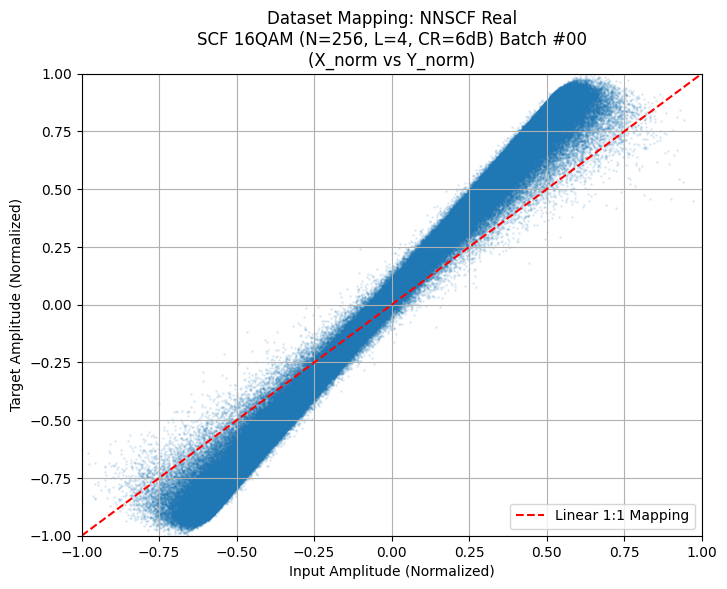

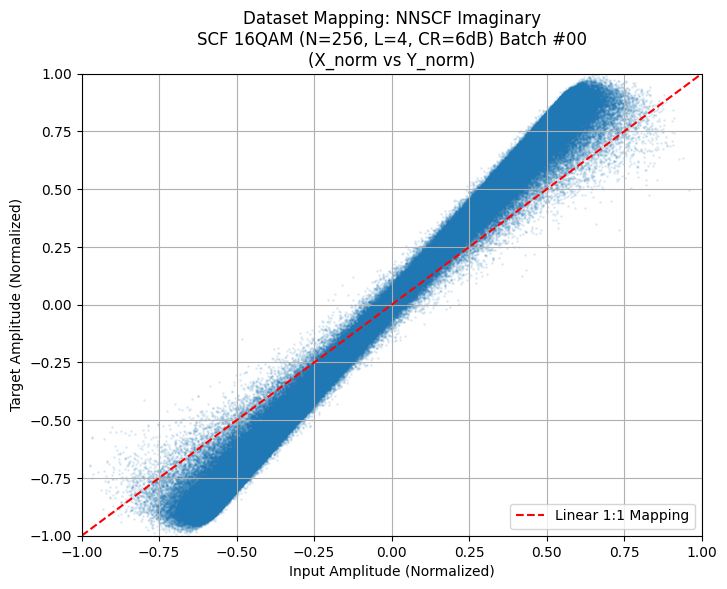

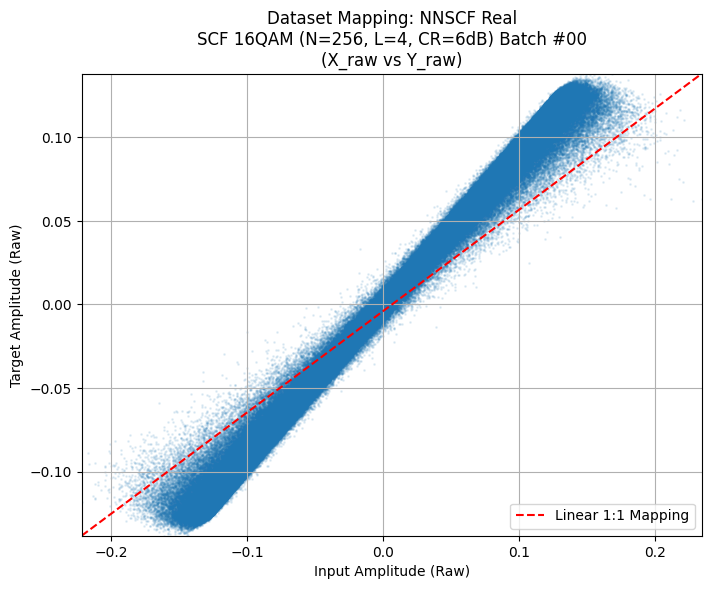

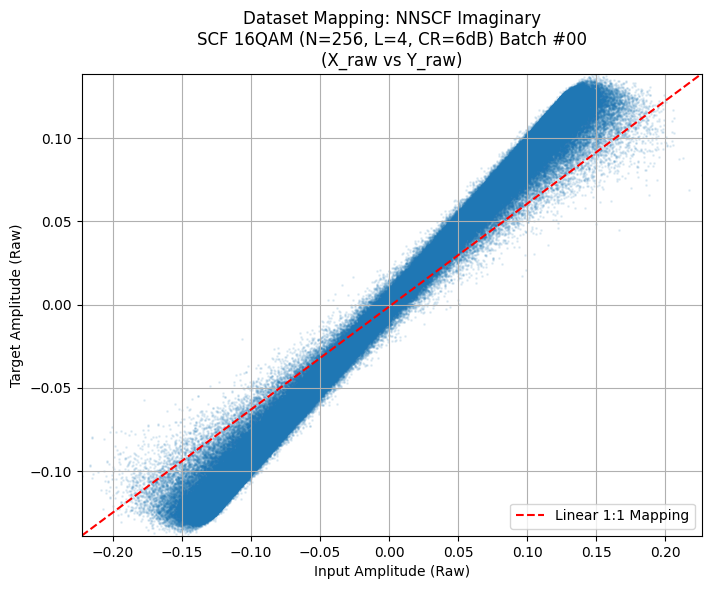

In [21]:
real_path = f"_method_{0:02d}_real"
imag_path = f"_method_{0:02d}_imag"
# ! raw is False as the "raw" values in old method are just wrongly normalized
plot_dataset_mapping(os.path.join(raw_dir, "old" + real_path + ".pt"), f"NNSCF Real\n{params} Batch #{0:02d}", raw=False, save=os.path.join(relev_dir, "old" + real_path + "_raw.png"))
plot_dataset_mapping(os.path.join(raw_dir, "old" + imag_path + ".pt"), f"NNSCF Imaginary\n{params} Batch #{0:02d}", raw=False, save=os.path.join(relev_dir, "old" + imag_path + "_raw.png"))

plot_dataset_mapping(os.path.join(raw_dir, "new" + real_path + ".pt"), f"NNSCF Real\n{params} Batch #{0:02d}", raw=True, save=os.path.join(relev_dir, "new" + real_path + "_raw.png"))
plot_dataset_mapping(os.path.join(raw_dir, "new" + imag_path + ".pt"), f"NNSCF Imaginary\n{params} Batch #{0:02d}", raw=True, save=os.path.join(relev_dir, "new" + imag_path + "_raw.png"))

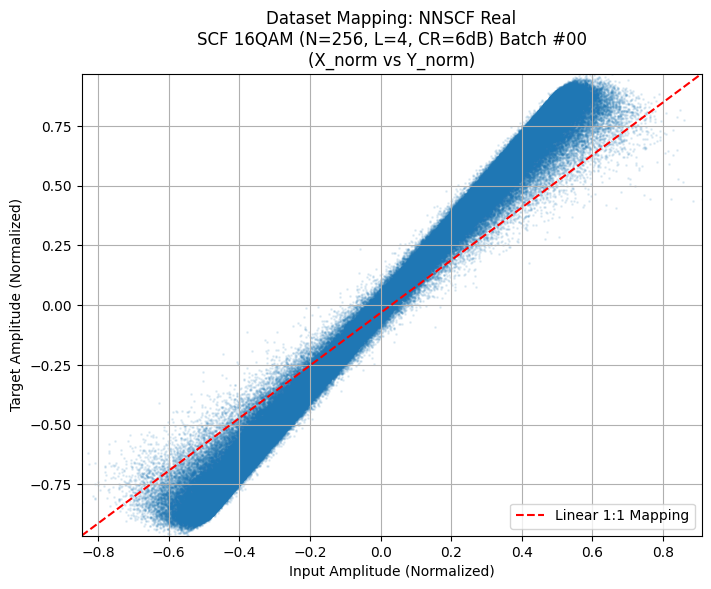

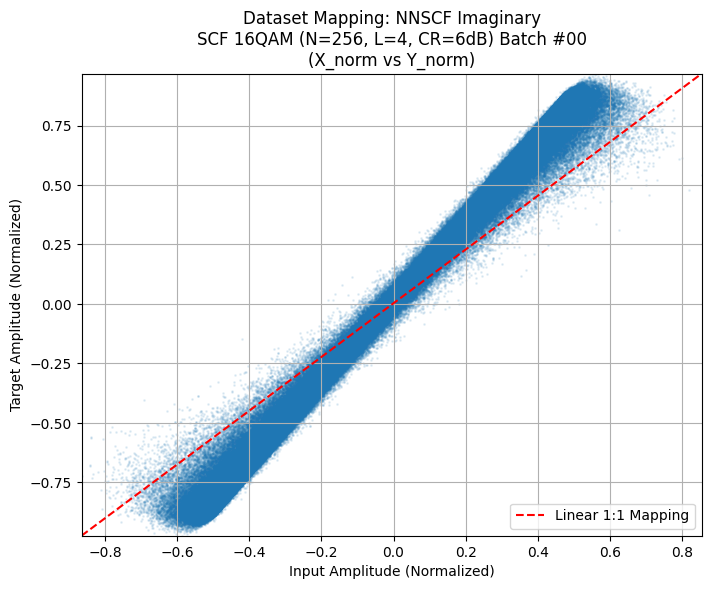

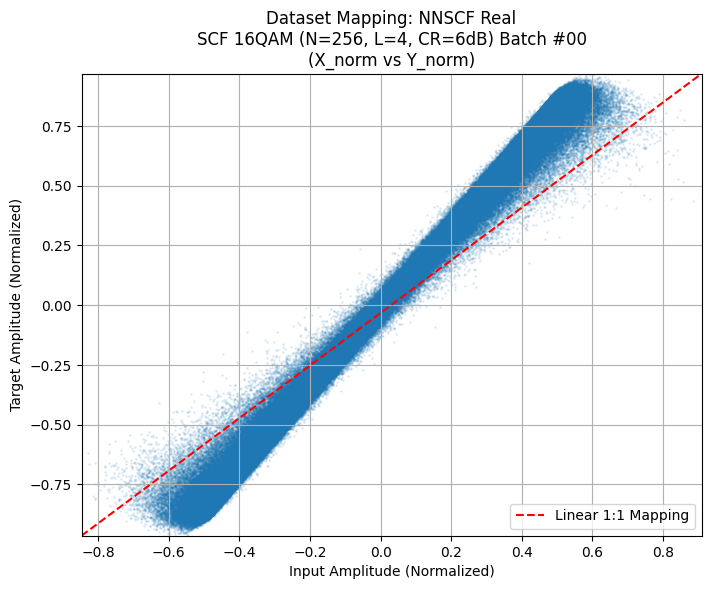

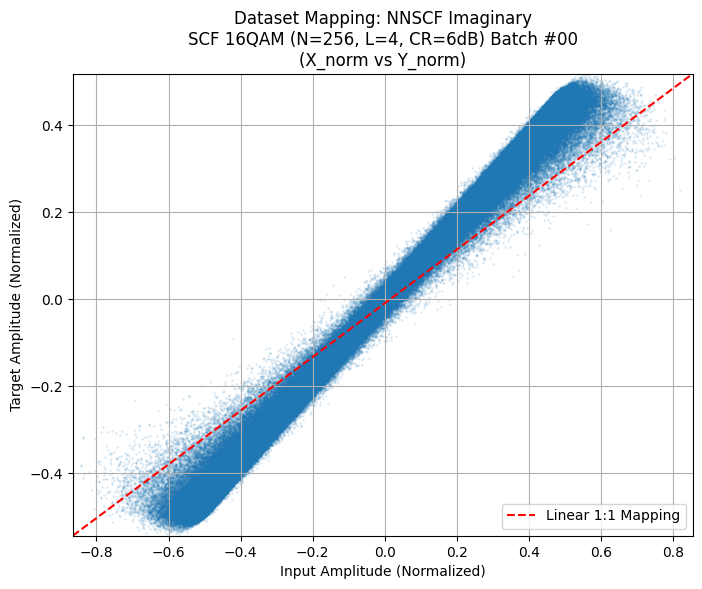

In [23]:
plot_dataset_mapping(os.path.join(norm_dir, "old" + real_path + ".pt"), f"NNSCF Real\n{params} Batch #{0:02d}", raw=False, save=os.path.join(relev_dir, "old" + real_path + "_norm.png"))
plot_dataset_mapping(os.path.join(norm_dir, "old" + imag_path + ".pt"), f"NNSCF Imaginary\n{params} Batch #{0:02d}", raw=False, save=os.path.join(relev_dir, "old" + imag_path + "_norm.png"))

plot_dataset_mapping(os.path.join(norm_dir, "new" + real_path + ".pt"), f"NNSCF Real\n{params} Batch #{0:02d}", raw=False, save=os.path.join(relev_dir, "new" + real_path + "_norm.png"))
plot_dataset_mapping(os.path.join(norm_dir, "new" + imag_path + ".pt"), f"NNSCF Imaginary\n{params} Batch #{0:02d}", raw=False, save=os.path.join(relev_dir, "new" + imag_path + "_norm.png"))